Device: cuda
Scanning dataset folders...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 



  Training (LiDAR Only) w/ Aux Mask Head | Epochs 30 | Compare TRAIN vs TEST
Ep 01/30 | LR: 4.99e-04  ✓ saved  | no_improve: 0/7
  Train -> Tot Loss: 0.2068 | Cls Loss: 0.0814 | AUC: 0.6919 | F1: 0.6451
  Test  -> Tot Loss: 0.1749 | Cls Loss: 0.0804 | AUC: 0.6840 | F1: 0.4816
Ep 02/30 | LR: 4.95e-04  ✓ saved  | no_improve: 0/7
  Train -> Tot Loss: 0.1701 | Cls Loss: 0.0709 | AUC: 0.7874 | F1: 0.7042
  Test  -> Tot Loss: 0.1664 | Cls Loss: 0.0750 | AUC: 0.6965 | F1: 0.5567
Ep 03/30 | LR: 4.88e-04  | no_improve: 1/7
  Train -> Tot Loss: 0.1637 | Cls Loss: 0.0675 | AUC: 0.8106 | F1: 0.7236
  Test  -> Tot Loss: 0.1725 | Cls Loss: 0.0833 | AUC: 0.6834 | F1: 0.5270
Ep 04/30 | LR: 4.78e-04  ✓ saved  | no_improve: 0/7
  Train -> Tot Loss: 0.1568 | Cls Loss: 0.0626 | AUC: 0.8420 | F1: 0.7466
  Test  -> Tot Loss: 0.1678 | Cls Loss: 0.0798 | AUC: 0.7292 | F1: 0.5449
Ep 05/30 | LR: 4.67e-04  | no_improve: 1/7
  Train -> Tot Loss: 0.1515 | Cls Loss: 0.0586 | AUC: 0.8669 | F1: 0.7763
  Test  -> Tot

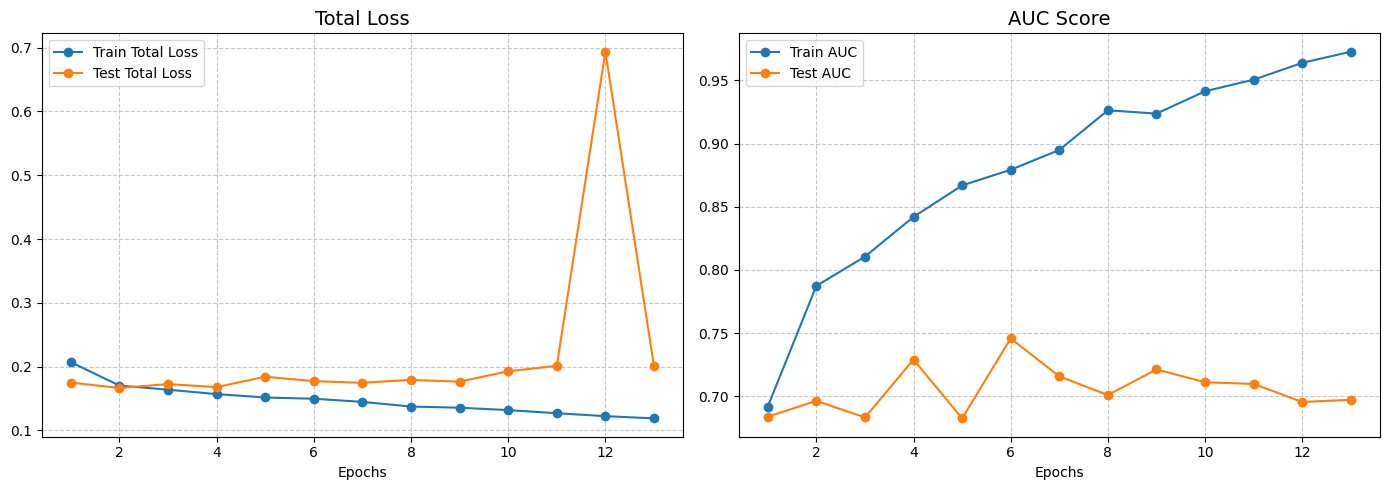

In [2]:
# !pip install -q rasterio  # uncomment if needed
import os, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
import torchvision.transforms.functional as TF
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, precision_recall_curve

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    ROOT          = Path('/kaggle/input/datasets/shreyansdeshpande/2nd-variation/FINALCNNDATA_NEW_01')
    OUTPUT_DIR    = Path('/kaggle/working')
    
    TRAIN_SITE    = ROOT / 'train' / 'site'
    TRAIN_NOSITE  = ROOT / 'train' / 'no_site'
    VAL_SITE      = ROOT / 'validation' / 'site'
    VAL_NOSITE    = ROOT / 'validation' / 'no_site'
    TEST_SITE     = ROOT / 'test' / 'site'
    TEST_NOSITE   = ROOT / 'test' / 'no_site'
    
    IMG_SUFFIX    = '.tif'
    # Training strictly on LiDAR indices: HS0, HS1, HS2, HS3, LRM, slope, SVF
    LIDAR_BANDS   = [4, 5, 6, 7, 8, 9, 10]   

    NUM_LIDAR_CH      = 7
    NUM_CLASSES       = 1
    PRETRAINED        = True
    FREEZE_BACKBONES  = True  
    DROPOUT           = 0.5   
    UNFREEZE_BLOCKS   = 5

    IMG_SIZE     = 250
    BATCH_SIZE   = 16
    NUM_EPOCHS   = 30
    PATIENCE     = 7
    LR           = 5e-4
    WEIGHT_DECAY = 1e-3
    MASK_WEIGHT  = 0.5    # Weight of auxiliary mask loss vs focal loss
    SEED         = 42
    NUM_WORKERS  = 2
    USE_AMP      = False

    T_MAX   = NUM_EPOCHS
    ETA_MIN = 1e-6

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')
 
    def forward(self, inputs, targets):
        bce_loss = self.bce_with_logits(inputs, targets)
        pt = torch.exp(-bce_loss)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

def combined_loss(class_logits, mask_logits, class_targets, mask_targets):
    cls_loss = BinaryFocalLoss()(class_logits, class_targets)
    
    # Downsample mask targets to match the auxiliary head output
    b, c, h, w = mask_logits.shape
    mask_targets_down = F.interpolate(mask_targets.unsqueeze(1), size=(h, w), mode='bilinear', align_corners=False)
    
    msk_loss = nn.BCEWithLogitsLoss()(mask_logits, mask_targets_down)
    
    total_loss = cls_loss + (CFG.MASK_WEIGHT * msk_loss)
    return total_loss, cls_loss, msk_loss

# ══════════════════════════════════════════════════════════════════════════════
# BUILD DATAFRAMES
# ══════════════════════════════════════════════════════════════════════════════
def folder_to_df(site_dir: Path, nosite_dir: Path) -> pd.DataFrame:
    rows = []
    for label, folder in [(1, site_dir), (0, nosite_dir)]:
        files = list(folder.glob(f'*{CFG.IMG_SUFFIX}'))
        for f in sorted(files):
            rows.append({'filepath': str(f), 'label': label})
    return pd.DataFrame(rows, columns=['filepath', 'label'])

print('Scanning dataset folders...')
train_df = folder_to_df(CFG.TRAIN_SITE,  CFG.TRAIN_NOSITE)
val_df   = folder_to_df(CFG.VAL_SITE,    CFG.VAL_NOSITE)
test_df  = folder_to_df(CFG.TEST_SITE,   CFG.TEST_NOSITE)

if len(train_df) == 0: raise FileNotFoundError("Training DataFrame is empty!")

# ══════════════════════════════════════════════════════════════════════════════
# DATASET & MULTI-BAND UNSUPERVISED MASK
# ══════════════════════════════════════════════════════════════════════════════
def load_patch(path: str) -> np.ndarray:
    import rasterio
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)

def per_channel_normalize(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        ch = arr[c]
        out[c] = (ch - ch.mean()) / (ch.std() + 1e-6)
    return out

def generate_unsupervised_mask(patch_tensor: torch.Tensor, band_indices: list, kernel_size: int = 5) -> torch.Tensor:
    """
    Computes a parameter-free, multi-channel max-combination mask.
    Normalizes each channel independently to handle unit discrepancies,
    then combines them so any high-texture region in ANY band is highlighted.
    """
    _, h, w = patch_tensor.shape
    max_variance_map = torch.zeros((h, w), dtype=torch.float32, device=patch_tensor.device)
    
    for idx in band_indices:
        x = patch_tensor[idx].unsqueeze(0).unsqueeze(0)  # Shape: [1, 1, H, W]
        
        # Local Variance = E[X^2] - (E[X])^2
        mean_x = F.avg_pool2d(x, kernel_size, stride=1, padding=kernel_size//2)
        mean_x2 = F.avg_pool2d(x**2, kernel_size, stride=1, padding=kernel_size//2)
        variance = mean_x2 - mean_x**2
        variance = torch.clamp(variance, min=0.0).squeeze(0).squeeze(0)  # Shape: [H, W]
        
        # Normalize this channel's variance to [0, 1] independently
        var_max = variance.max()
        if var_max > 1e-8:
            variance = variance / var_max
            
        # Combine using MAX rule
        max_variance_map = torch.max(max_variance_map, variance)
        
    # Final safety normalization to [0, 1]
    final_max = max_variance_map.max()
    if final_max > 1e-8:
        max_variance_map = max_variance_map / final_max
        
    return max_variance_map.unsqueeze(0)  # Shape: [1, H, W]

class ArchSiteDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool = True):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train
        
    def __len__(self): return len(self.df)
    
    def _augment(self, t):
        if random.random() > 0.5: t = TF.hflip(t)
        if random.random() > 0.5: t = TF.vflip(t)
        angle = random.choice([0, 90, 180, 270])
        if angle: t = TF.rotate(t, angle)
        if random.random() > 0.5:
              t = t + torch.randn_like(t) * 0.02
        return t
        
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        t = torch.from_numpy(per_channel_normalize(load_patch(row['filepath'])))
        t = TF.resize(t, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        
        # Generates mask leveraging ALL LiDAR bands via MAX combination
        mask_t = generate_unsupervised_mask(t, band_indices=CFG.LIDAR_BANDS, kernel_size=5)
        
        # Concat to augment image and mask synchronously
        t = torch.cat([t, mask_t], dim=0)
        
        if self.is_train:
            t = self._augment(t)
            
        mask_aug = t[-1] 
        t_img = t[:-1]   
        
        return t_img[CFG.LIDAR_BANDS], mask_aug, torch.tensor(row['label'], dtype=torch.float32)

class ArchSiteTestDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        t = torch.from_numpy(per_channel_normalize(load_patch(row['filepath'])))
        t = TF.resize(t, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        
        mask_t = generate_unsupervised_mask(t, band_indices=CFG.LIDAR_BANDS, kernel_size=5)
        
        return t[CFG.LIDAR_BANDS], mask_t.squeeze(0), Path(row['filepath']).name

# ══════════════════════════════════════════════════════════════════════════════
# DUAL-HEAD MODEL (CLASSIFICATION + AUX MASK)
# ══════════════════════════════════════════════════════════════════════════════
class LiDAREfficientNetWithAux(nn.Module):
    def __init__(self, in_channels: int = 7, num_classes: int = 1,
                 pretrained: bool = True, freeze_backbones: bool = True,
                 dropout: float = 0.5, unfreeze_last_n_blocks: int = 5):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights)
 
        old_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=old_conv.bias is not None,
        )
        if pretrained:
            with torch.no_grad():
                mean_w = old_conv.weight.mean(dim=1, keepdim=True)
                new_conv.weight.copy_(mean_w.repeat(1, in_channels, 1, 1))
 
        self.backbone.features[0][0] = new_conv
 
        if freeze_backbones:
            for param in self.backbone.features.parameters():
                param.requires_grad = False
            for param in self.backbone.features[0][0].parameters():
                param.requires_grad = True
            total_blocks = len(self.backbone.features)
            for block in self.backbone.features[total_blocks - unfreeze_last_n_blocks:]:
                for param in block.parameters():
                    param.requires_grad = True
 
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes)
        )
        
        self.mask_head = nn.Sequential(
            nn.Conv2d(in_features, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 1, kernel_size=1)
        )
 
    def forward(self, x):
        features = self.backbone.features(x)
        pooled = self.backbone.avgpool(features).flatten(1)
        class_logits = self.backbone.classifier(pooled)
        mask_logits = self.mask_head(features)
        
        return class_logits, mask_logits

def get_model():
    return LiDAREfficientNetWithAux(
        in_channels=CFG.NUM_LIDAR_CH,
        num_classes=CFG.NUM_CLASSES,
        pretrained=CFG.PRETRAINED,
        freeze_backbones=CFG.FREEZE_BACKBONES,
        dropout=CFG.DROPOUT,
        unfreeze_last_n_blocks=CFG.UNFREEZE_BLOCKS
    ).to(DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []
    
    for lidar, mask_targets, labels in loader:
        lidar = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.USE_AMP):
            class_logits, mask_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(class_logits.squeeze(1), mask_logits, labels, mask_targets)
            
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_cls_loss += cls_loss.item() * batch_size
        total_msk_loss += msk_loss.item() * batch_size
        
        all_preds.extend(torch.sigmoid(class_logits).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    
    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset), 
            auc, f1_score(all_labels, bin_preds, zero_division=0))

@torch.no_grad()
def valid_epoch(model, loader):
    model.eval()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []
    
    for lidar, mask_targets, labels in loader:
        lidar = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        with autocast(enabled=CFG.USE_AMP):
            class_logits, mask_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(class_logits.squeeze(1), mask_logits, labels, mask_targets)
            
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_cls_loss += cls_loss.item() * batch_size
        total_msk_loss += msk_loss.item() * batch_size
        
        all_preds.extend(torch.sigmoid(class_logits).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    
    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset), 
            auc, f1_score(all_labels, bin_preds, zero_division=0))

# ══════════════════════════════════════════════════════════════════════════════
# DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
class_counts = train_df['label'].value_counts().to_dict()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

trn_loader = DataLoader(ArchSiteDataset(train_df, is_train=True),
                        batch_size=CFG.BATCH_SIZE, sampler=sampler, 
                        num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)

test_loader = DataLoader(ArchSiteDataset(test_df, is_train=False),
                        batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                        num_workers=CFG.NUM_WORKERS, pin_memory=True)

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN
# ══════════════════════════════════════════════════════════════════════════════
model     = get_model()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=CFG.ETA_MIN)
scaler    = GradScaler(enabled=CFG.USE_AMP)

best_auc = 0.0
epochs_no_improve = 0
ckpt_path = CFG.OUTPUT_DIR / 'efficientnet_b0_lidar_best.pth'

print(f'\n{"="*65}')
print(f'  Training (LiDAR Only) w/ Aux Mask Head | Epochs {CFG.NUM_EPOCHS} | Compare TRAIN vs TEST')
print(f'{"="*65}')

history = {'train_loss': [], 'train_auc': [], 'test_loss': [], 'test_auc': []}

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    trn_loss, trn_cls_loss, trn_auc, trn_f1 = train_epoch(model, trn_loader, optimizer, scaler)
    tst_loss, tst_cls_loss, tst_auc, tst_f1 = valid_epoch(model, test_loader)

    scheduler.step()

    history['train_loss'].append(trn_loss)
    history['test_loss'].append(tst_loss)
    history['train_auc'].append(trn_auc)
    history['test_auc'].append(tst_auc)

    saved = ''
    if tst_auc > best_auc:
        best_auc = tst_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        saved = '  ✓ saved'
    else:
        epochs_no_improve += 1

    print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}{saved}'
          f'  | no_improve: {epochs_no_improve}/{CFG.PATIENCE}')
    print(f'  Train -> Tot Loss: {trn_loss:.4f} | Cls Loss: {trn_cls_loss:.4f} | AUC: {trn_auc:.4f} | F1: {trn_f1:.4f}')
    print(f'  Test  -> Tot Loss: {tst_loss:.4f} | Cls Loss: {tst_cls_loss:.4f} | AUC: {tst_auc:.4f} | F1: {tst_f1:.4f}')

    if epochs_no_improve >= CFG.PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch} '
              f'(no improvement in test AUC for {CFG.PATIENCE} consecutive epochs).')
        break

# ══════════════════════════════════════════════════════════════════════════════
# PLOT FINAL TRAINING HISTORY
# ══════════════════════════════════════════════════════════════════════════════
def plot_full_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(epochs, history['train_loss'], label='Train Total Loss', marker='o')
    axes[0].plot(epochs, history['test_loss'], label='Test Total Loss', marker='o')
    axes[0].set_title('Total Loss', fontsize=14)
    axes[0].set_xlabel('Epochs')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    axes[1].plot(epochs, history['train_auc'], label='Train AUC', marker='o')
    axes[1].plot(epochs, history['test_auc'], label='Test AUC', marker='o')
    axes[1].set_title('AUC Score', fontsize=14)
    axes[1].set_xlabel('Epochs')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

plot_full_history(history)